In [26]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
import scipy.stats
from typing import List, Tuple, Dict
from matplotlib.gridspec import GridSpec
from scipy.stats import poisson
import seaborn as sns

# グラフの色指定
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]

# グラフ全体のフォント設定
plt.rcParams['font.family'] = 'serif'  # 全体のフォントをSerifに設定
plt.rcParams['mathtext.fontset'] = 'cm'  # 数式のフォントをComputer Modernに設定
plt.rcParams['mathtext.rm'] = 'serif'  # TeXの通常フォントをSerifに設定
plt.rcParams['font.size'] = 18  # デフォルトフォントサイズ
plt.rcParams['axes.labelsize'] = 18  # 軸ラベルのフォントサイズ
plt.rcParams['axes.titlesize'] = 22  # タイトルのフォントサイズ
plt.rcParams['legend.fontsize'] = 16  # 凡例のフォントサイズ
plt.rcParams['grid.color'] = 'gray'  # グリッドの色を薄い灰色に設定
plt.rcParams['grid.linestyle'] = ':'  # グリッドを点線に設定
plt.rcParams['grid.linewidth'] = 0.5  # グリッドの線幅を設定

In [ ]:
"""
Load SIS simulation event times output by the Java App into a NumPy array.

- Input directory: `output/sis`
  - `metadata.csv` for parameters (itr, batch_num, c_list, lambda range)
  - `times_XX.txt` where each line is a comma-separated list of event times

- Output array `time`: shape = (len(cList), len(lambdaList), itr), dtype=object
  Each element is a 1D NumPy array of float64 event times for a single run.

Usage:
    from scripts.load_sis_time import load_time_array
    time, axes = load_time_array(output_dir="output/sis", batch_idx=0)
    # time.shape -> (C, L, itr)
    # axes["c_list"], axes["lambda_list"], axes["itr"]
"""

from __future__ import annotations

output_path = os.path.abspath(os.path.join('..', 'downloaded/RR/z=6/N=10000final'))
# output_path = os.path.abspath(os.path.join('..', 'java-project', 'output'))
if output_path not in sys.path:
    sys.path.append(output_path)

def _read_params(params_path: str) -> Dict[str, str]:
    params = pd.read_csv(params_path)
    network_type = params['networkType'].values[0]
    N = params['N'].values[0]
    k_ave = params['k_ave'].values[0]
    lambda_list = params['lambdaList'].values[0]
    gamma = params['gamma'].values[0]
    rho0 = params['rho0'].values[0]
    tmax = params['tmax'].values[0]
    c_list = params['cList'].values[0]
    seed = params['seed'].values[0]
    itr = params['itr'].values[0]
    batchNum = params['batchNum'].values[0]

    c_list = c_list.split(":")
    c_list = [float(c) for c in c_list]

    lamb_values = lambda_list.split(":")
    lamb_values = [float(lamb) for lamb in lamb_values]

    return network_type, N, k_ave, gamma, rho0, tmax, seed, itr, batchNum, c_list, lamb_values


def _read_metadata(meta_path: str = os.path.join(output_path, "metadata.csv")) -> Dict[str, str]:
    """Read key,value style metadata where values may contain commas.

    This parser splits each line at the first comma only.
    Returns a dict of raw string values.
    """
    meta: Dict[str, str] = {}
    with open(meta_path, "r", encoding="utf-8") as f:
        # skip header if present
        header = f.readline()
        if "," not in header:
            # Unexpected; treat as data line
            key, val = header.strip().split(",", 1)
            meta[key.strip()] = val.strip()
        for line in f:
            line = line.rstrip("\n")
            if not line:
                continue
            if "," not in line:
                continue
            key, val = line.split(",", 1)
            meta[key.strip()] = val.strip()
    return meta


def load_batch(output_dir: str, batch_idx: int, ) -> Tuple[np.ndarray, np.ndarray]:
    params_path = os.path.join(output_dir, "params.csv")
    if not os.path.exists(params_path):
        raise FileNotFoundError(f"params.csv not found in {output_dir}")

    _, _, _, _, _, _, _, itr, _, c_list, lambda_values = _read_params(params_path)

    C, L = len(c_list), len(lambda_values)
    expected = C * L * itr

    times_file = os.path.join(output_dir, f"times_{batch_idx:02d}.txt")
    infected_file = os.path.join(output_dir, f"infected_num_{batch_idx:02d}.txt")
    if not os.path.exists(times_file) or not os.path.exists(infected_file):
        raise FileNotFoundError(f"Missing times or infected file for batch {batch_idx:02d}")

    time = np.empty((C, L, itr), dtype=object)
    infected = np.empty((C, L, itr), dtype=object)

    # Initialize with empty arrays to avoid uninitialized slots
    for c in range(C):
        for l in range(L):
            for i in range(itr):
                time[c, l, i] = np.array([], dtype=float)
                infected[c, l, i] = np.array([], dtype=int)

    # Iterate paired lines; stop when either file ends
    tcount = icount = 0
    with open(times_file, "r", encoding="utf-8", errors="ignore") as tf, open(infected_file, "r", encoding="utf-8", errors="ignore") as inf:
        while True:
            tline = tf.readline()
            iline = inf.readline()
            if not tline or not iline:
                break
            ts = tline.strip()
            is_ = iline.strip()
            tarr = np.fromstring(ts, sep=",", dtype=float) if ts else np.array([], dtype=float)
            iarr = np.fromstring(is_, sep=",", dtype=int) if is_ else np.array([], dtype=int)

            flat_idx = tcount  # counts paired lines
            if flat_idx >= expected:
                break
            cIdx = flat_idx // (L * itr)
            rem = flat_idx % (L * itr)
            lIdx = rem // itr
            itIdx = rem % itr
            time[cIdx, lIdx, itIdx] = tarr
            infected[cIdx, lIdx, itIdx] = iarr
            tcount += 1
            icount += 1

    # If files contain additional lines beyond expected, ignore extras silently.
    # If fewer lines, warn but do not raise.
    if tcount < expected or icount < expected:
        missing = expected - min(tcount, icount)
        print(
            f"[WARN] Batch {batch_idx:02d}: filled {min(tcount, icount)} / {expected} runs; "
            f"{missing} missing. Unfilled slots remain empty arrays.")

    return time, infected

def load(path: str = output_path, max_file_num: int = 1e5) -> Tuple[np.ndarray, np.ndarray, Dict[str, object]]:
    network_type, N, k_ave, gamma, rho0, tmax, seed, itr, batchNum, c_list, lamb_values = _read_params(os.path.join(path, "params.csv"))

    valid_batch_idx = []
    valid_file_num = 0

    for batch_idx in range(batchNum):
        if os.path.exists(os.path.join(path, f"times_{batch_idx:02d}.txt")) and os.path.exists(os.path.join(path, f"infected_num_{batch_idx:02d}.txt")):
            print(f"idx: {batch_idx}, {valid_file_num}th file is found")
            valid_batch_idx.append(batch_idx)
            valid_file_num += 1
            if valid_file_num >= max_file_num:
                break

    total_itr = len(valid_batch_idx) * itr
    shape = (len(c_list), len(lamb_values), total_itr)
    times_all = np.zeros(shape, dtype=object)
    infected_num_all = np.zeros(shape, dtype=object)  # 修正: dtype=object

    print("")
    print(f"Lets load {valid_file_num} files!")

    for batch_idx in valid_batch_idx:
        print(f" --> Loading {batch_idx}th file...")
        times, infected_num = load_batch(path, batch_idx)
        times_all[:, :, batch_idx * itr : (batch_idx + 1) * itr] = times
        infected_num_all[:, :, batch_idx * itr : (batch_idx + 1) * itr] = infected_num

    axes = {
        "network_type": network_type,
        "N": N,
        "k_ave": k_ave,
        "gamma": gamma,
        "rho0": rho0,
        "tmax": tmax,
        "seed": seed,
        "total_itr": total_itr,
        "c_list": c_list,
        "lamb_values": lamb_values,
    }

    return times_all, infected_num_all, axes

In [28]:
# y(Theta)を計算する関数
def y_SIS(deg_list, pk, lamb, gamma, Theta, c=0):
    # 平均次数 <k> = Σ k*p(k)
    k_ave = np.sum(deg_list * pk)
    if k_ave == 0:
        return -Theta

    y = 0
    for k, p in zip(deg_list, pk):
        gamma_bar = gamma / (1 + c * k * Theta)
        y += k * p * lamb * k * Theta / (gamma_bar + lamb * k * Theta)
    
    y /= k_ave
    y -= Theta
    return y

# y'(Theta) = dy/dTheta を計算する関数
def dy_dTheta_SIS(deg_list, pk, lamb, gamma, Theta, c=0.0):
    k_ave = np.sum(deg_list * pk)
    if k_ave == 0:
        return -1.0
    dy = 0.0
    for k, p in zip(deg_list, pk):
        B = gamma + lamb * k * Theta * (1.0 + c * k * Theta)  # 正しい分母
        if B == 0:
            return np.nan
        fprime = (lamb * gamma * k * (1.0 + 2.0 * c * k * Theta)) / (B ** 2)
        dy += k * p * fprime
    dy /= k_ave
    dy -= 1.0
    return dy


# ニュートン法を実装した関数
def newton_method(deg_list, pk, lamb, gamma, Theta_initial=0.9, tolerance=1e-16, max_iter=100, c=0):
    """
    ニュートン法を用いて y_SIS(Theta) = 0 となるThetaを探す
    """
    Theta = Theta_initial
    for i in range(max_iter):
        y_val = y_SIS(deg_list, pk, lamb, gamma, Theta, c)
        
        # yが十分に0に近ければ終了
        if abs(y_val) < tolerance:
            return Theta

        dy_val = dy_dTheta_SIS(deg_list, pk, lamb, gamma, Theta, c)

        # 導関数が0に近く、更新が発散しそうな場合は終了
        if abs(dy_val) < 1e-10:
            # print(f"Warning: Derivative is too small at lambda={lamb}, Theta={Theta}. Stopping.")
            return Theta

        # ニュートン法の更新式
        Theta_new = Theta - y_val / dy_val
        
        # 更新量が十分に小さくなれば終了
        if abs(Theta_new - Theta) < tolerance:
            return Theta_new
            
        Theta = Theta_new
        
    # print(f"Warning: Newton's method did not converge for lambda={lamb} within {max_iter} iterations.")
    return Theta

def theta_to_I(deg_list, pk, lamb, gamma, Theta, c=0):
    k_ave = np.sum(deg_list * pk)
    if k_ave == 0:
        return 0
    I = 0
    for k, p in zip(deg_list, pk):
        gamma_bar = gamma / (1 + c * k * Theta)
        I += k * p * lamb * k * Theta / (gamma_bar + lamb * k * Theta)
    I /= k_ave
    return I

def theta_symbolic_RR_numeric(lamb: float, K: float, gamma: float, c: float) -> float:
    """
    RR（正則）ネットワークの閉形式解を用いて Theta(λ) を数値的に返す。
    - c=0 のとき: Theta = max(0, 1 - gamma/(lambda*K))
    - c>0 のとき: 2次方程式の正の根を使用。
    物理的制約に合わせて [0,1] にクリップする。
    """
    if lamb <= 0:
        return 0.0
    if c == 0:
        theta = 1.0 - gamma / (lamb * K)
        return float(np.clip(theta, 0.0, 1.0))
    a = c * K
    b = 1.0 - c * K
    c0 = gamma / (lamb * K) - 1.0
    D = b * b - 4.0 * a * c0
    if D < 0:
        return 0.0
    theta = (-b + np.sqrt(D)) / (2.0 * a)
    return float(np.clip(theta, 0.0, 1.0))

In [29]:
times_all, infected_num_all, axes = load()
meta = _read_metadata()
network_type = axes["network_type"]
N = axes["N"]
k_ave = axes["k_ave"]
gamma = axes["gamma"]
rho0 = axes["rho0"]
tmax = axes["tmax"]
seed = axes["seed"]
total_itr = axes["total_itr"]
c_list = axes["c_list"]
lamb_values = axes["lamb_values"]

idx: 0, 0th file is found
idx: 1, 1th file is found
idx: 2, 2th file is found
idx: 3, 3th file is found
idx: 4, 4th file is found
idx: 5, 5th file is found
idx: 6, 6th file is found
idx: 7, 7th file is found
idx: 8, 8th file is found
idx: 9, 9th file is found
idx: 10, 10th file is found
idx: 11, 11th file is found
idx: 12, 12th file is found
idx: 13, 13th file is found
idx: 14, 14th file is found
idx: 15, 15th file is found
idx: 16, 16th file is found
idx: 17, 17th file is found
idx: 18, 18th file is found
idx: 19, 19th file is found
idx: 20, 20th file is found
idx: 21, 21th file is found
idx: 22, 22th file is found
idx: 23, 23th file is found
idx: 24, 24th file is found
idx: 25, 25th file is found
idx: 26, 26th file is found
idx: 27, 27th file is found
idx: 28, 28th file is found
idx: 29, 29th file is found
idx: 30, 30th file is found
idx: 31, 31th file is found

Lets load 32 files!
 --> Loading 0th file...
 --> Loading 1th file...
 --> Loading 2th file...
 --> Loading 3th file...
 --

In [30]:
print("==== shape ====")
print(times_all.shape)
print(infected_num_all.shape)

print("")
print("==== params ====")
print(f"network_type: {network_type}")
print(f"N: {N}")
print(f"k_ave: {k_ave}")
print(f"gamma: {gamma}")
print(f"rho0: {rho0}")
print(f"tmax: {tmax}")
print(f"seed: {seed}")
print(f"total_itr: {total_itr}")

print("")
print("==== meta data ====")
for key, value in meta.items():
    print(f"{key}: {value}")

==== shape ====
(101, 101, 320)
(101, 101, 320)

==== params ====
network_type: RR
N: 10000
k_ave: 6
gamma: 1.0
rho0: 1.0
tmax: 200.0
seed: 0.0
total_itr: 320

==== meta data ====
start_time: 2025-09-12 03:52:30
end_time: 2025-09-12 05:06:14
duration_seconds: 4424.150
network_type: RR
runs_per_batch: 102010
total_runs: 3264320
seed_base: 0
os_name: Linux
os_version: 6.1.147-172.266.amzn2023.aarch64
java_version: 17.0.16
java_vendor: Amazon.com Inc.
cpu_cores: 32
total_memory_mb: 6600
max_memory_mb: 15784


In [31]:
test_lamb_idx_list = [0, 2, 10, 20, 30]
test_lamb_idx_list = np.array(test_lamb_idx_list, dtype=int)

lamb_size = len(lamb_values)
lamb_idx_list = []
for i in test_lamb_idx_list:
    if i < lamb_size:
        lamb_idx_list.append(i)

lamb_idx_list = np.array(lamb_idx_list)

In [32]:
threshold = -1

last_I = np.zeros((len(c_list), len(lamb_values), total_itr))
valid_last_I = np.zeros((len(c_list), len(lamb_values)))
valid_num = np.zeros((len(c_list), len(lamb_values)))
for c_idx in range(len(c_list)):
    for lamb_idx in range(len(lamb_values)):
        valid = []
        non_valid = []
        for itr_idx in range(len(infected_num_all[c_idx, lamb_idx])):
            last_I[c_idx, lamb_idx, itr_idx] = infected_num_all[c_idx, lamb_idx, itr_idx][-1]
            if last_I[c_idx, lamb_idx, itr_idx] > threshold:
                valid.append(last_I[c_idx, lamb_idx, itr_idx])
                valid_num[c_idx, lamb_idx] += 1
            else:
                non_valid.append(last_I[c_idx, lamb_idx, itr_idx])
        if len(valid) > 0:
            valid_last_I[c_idx, lamb_idx] = np.mean(valid)
        else:
            valid_last_I[c_idx, lamb_idx] = np.mean(non_valid)

valid_last_I /= N


In [33]:
lamb_values_for_theory = lamb_values
# lamb_values_for_theory = np.linspace(np.min(lamb_values), np.max(lamb_values), 1000)
theta_all = np.zeros((len(c_list), len(lamb_values_for_theory)))
I_theory = np.zeros((len(c_list), len(lamb_values_for_theory)))

for cidx, c in enumerate(c_list):
    theta_results = []

    # 各lambdaについてニュートン法でThetaを解く
    for lamb_idx, lamb in enumerate(lamb_values_for_theory):
        if network_type == "RR":
            # 次数のリスト
            deg_list = [k_ave]
            pk = np.array([1.0])
            solution = theta_symbolic_RR_numeric(lamb, k_ave, gamma, c)

        elif network_type == "ER":
            # 次数のリスト (ポアソン分布が意味を持つ範囲)
            # 平均の3倍+10程度あれば十分
            deg_list = np.arange(0, int(k_ave * 3) + 10)

            # 次数分布 p(k) を計算 (ポアソン分布)
            pk = scipy.stats.poisson.pmf(deg_list, k_ave)
            solution = newton_method(deg_list, pk, lamb, gamma, c=c)

        # elif network_type == "SF":
        #     deg_list = np.arange(1, 1000)

        #     C = (2 - kappa) * k_ave
        #     pk = C * deg_list ** (- kappa)

        else:
            raise ValueError(f"Invalid network type: {network_type}")

        # 初期値は重要。ここでは前のステップの結果を流用すると収束しやすいが、簡単のため固定値から始める
        # 問題によってはTheta=0も根になる（自明な解）ため、0以外の初期値を選ぶ
        # 物理的に意味のある解は [0,1] に収める
        solution = float(np.clip(solution, 0.0, 1.0))
        # print(f"{lamb:.4f}, {solution:.8f}")
        I_theory[cidx, lamb_idx] = theta_to_I(deg_list, pk, lamb, gamma, solution, c=c)



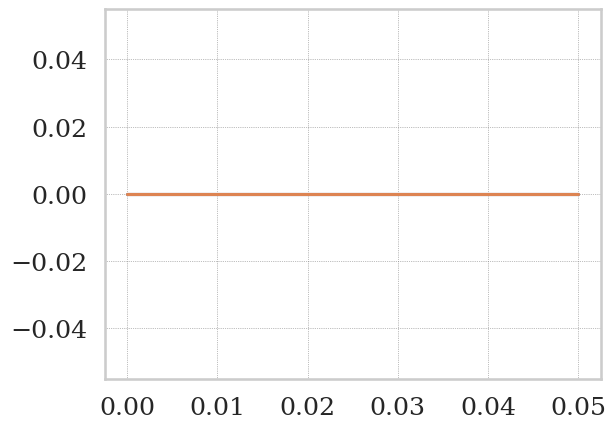

In [34]:
plt.plot(lamb_values, valid_last_I[0, :])
plt.plot(lamb_values, I_theory[0, :])

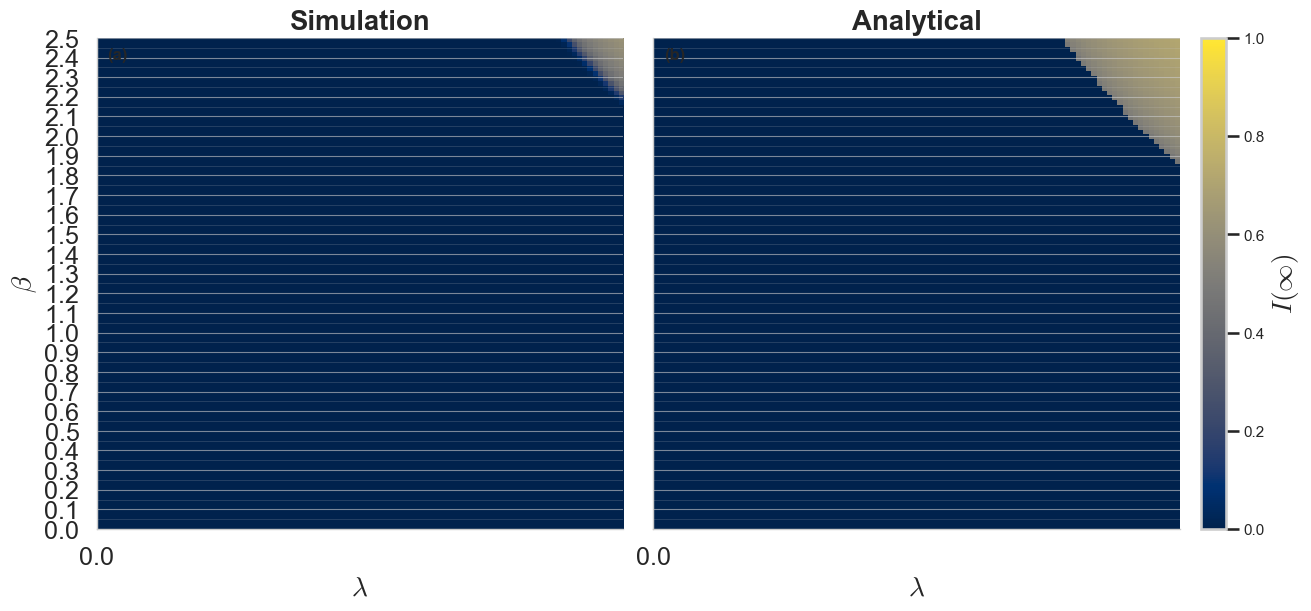

In [35]:
# === 可読性重視のプロット設定 ===
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

# Seabornスタイル（太字すぎないグリッド、視認性の高い配色）
sns.set_theme(context="talk", style="whitegrid", font_scale=1.1)

# 共有範囲（色のスケール統一）
vmin, vmax = 0.0, 1.0

# 軸範囲・目盛位置を先に定義（端がピッタリ揃う）
xmin, xmax = float(np.min(lamb_values)), float(np.max(lamb_values))
ymin, ymax = float(np.min(c_list)),      float(np.max(c_list))

# 図と軸（sharex/shareyで目盛・範囲を完全共有、constrained_layoutで余白自動調整）
fig, axes = plt.subplots(
    1, 2, figsize=(13, 6), sharex=True, sharey=True, constrained_layout=True
)

# 色覚多様性に配慮したカラーマップ（magma→cividis/viridis 推奨）
cmap = "cividis"  # お好みで "viridis" も可

# 共通のimshow引数
im_kwargs = dict(
    extent=[xmin, xmax, ymin, ymax],
    origin="lower",
    aspect="auto",
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    interpolation="nearest"  # ぼかさず数値境界が見える
)

# --- 左：Simulation ---
ax1 = axes[0]
im1 = ax1.imshow(valid_last_I[:, :], **im_kwargs)
ax1.set_title("Simulation", fontweight="bold")
ax1.set_xlabel(r"$\lambda$")
ax1.set_ylabel(r"$\beta$")

# --- 右：Analytical ---
ax2 = axes[1]
im2 = ax2.imshow(I_theory[:, :], **im_kwargs)
ax2.set_title("Analytical", fontweight="bold")
ax2.set_xlabel(r"$\lambda$")

# --- 目盛とグリッドの最適化 ---
# 主目盛を0.1刻み、補助目盛を0.05刻みに（値域に合わせて調整）
xtick_main, xtick_minor = 0.1, 0.05
ytick_main, ytick_minor = 0.1, 0.05

for ax in axes:
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.xaxis.set_major_locator(MultipleLocator(xtick_main))
    ax.xaxis.set_minor_locator(MultipleLocator(xtick_minor))
    ax.yaxis.set_major_locator(MultipleLocator(ytick_main))
    ax.yaxis.set_minor_locator(MultipleLocator(ytick_minor))

    # 小数1桁で統一
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))

    # グリッドは主目盛=やや強め、補助目盛=うすめ
    ax.grid(which="major", linewidth=0.8, alpha=0.6)
    ax.grid(which="minor", linewidth=0.5, alpha=0.25)

    # 余計な枠線を弱める
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_linewidth(1.0)

# --- 共有カラーバー（両軸にまたがる、ラベルは太字） ---
cbar = fig.colorbar(im2, ax=axes, location="right", fraction=0.035, pad=0.02)
cbar.set_label(r"$I(\infty)$", fontweight="bold")
cbar.ax.tick_params(labelsize=11)

# --- パネルラベル（任意） ---
axes[0].text(0.02, 0.98, "(a)", transform=axes[0].transAxes,
             va="top", ha="left", fontsize=12, fontweight="bold")
axes[1].text(0.02, 0.98, "(b)", transform=axes[1].transAxes,
             va="top", ha="left", fontsize=12, fontweight="bold")

plt.show()
